In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def resolveTablesDir() -> Path:
    for searchDir in [Path.cwd(), *Path.cwd().parents]:
        candidateFile = searchDir / "tables" / "directors.csv"
        if candidateFile.is_file():
            return searchDir / "tables"

tablesDir = resolveTablesDir()

In [4]:
directors = pd.read_csv(tablesDir / "directors.csv")
actors    = pd.read_csv(tablesDir / "actors.csv")
users     = pd.read_csv(tablesDir / "users.csv")
movies    = pd.read_csv(tablesDir / "movies.csv")
roles     = pd.read_csv(tablesDir / "roles.csv")
reviews   = pd.read_csv(tablesDir / "reviews.csv")

users["registrationDate"] = pd.to_datetime(users["registrationDate"])
reviews["reviewDate"]     = pd.to_datetime(reviews["reviewDate"])

tablesByName = {
    "directors": directors,
    "actors":    actors,
    "users":     users,
    "movies":    movies,
    "roles":     roles,
    "reviews":   reviews,
}

passLabel = "✅ PASS"
failLabel = "❌ FAIL"


def formatResult(ok, detail=""):
    tag = passLabel if ok else failLabel
    return f"{tag}  {detail}".strip()

print("Tables loaded:")
for name, df in tablesByName.items():
    print(f"  {name:<12} {len(df):>8,} rows  ×  {df.shape[1]} cols")

Tables loaded:
  directors       1,000 rows  ×  3 cols
  actors          5,000 rows  ×  4 cols
  users          50,000 rows  ×  4 cols
  movies         10,000 rows  ×  6 cols
  roles         200,000 rows  ×  3 cols
  reviews       150,000 rows  ×  5 cols


In [5]:
print("=" * 60)
print("CHECK 1 · COMPLETENESS  (no NULLs / NaNs)")
print("=" * 60)

allPass = True
for name, df in tablesByName.items():
    nullCounts = df.isnull().sum()
    anyNull = nullCounts.any()
    if anyNull:
        allPass = False
        badCols = nullCounts[nullCounts > 0].to_dict()
        print(f"  {name:<12}  {failLabel}  null columns → {badCols}")
    else:
        print(f"  {name:<12}  {passLabel}  0 nulls across {df.shape[1]} columns")

print()
print("Overall:", passLabel if allPass else failLabel)

CHECK 1 · COMPLETENESS  (no NULLs / NaNs)
  directors     ✅ PASS  0 nulls across 3 columns
  actors        ✅ PASS  0 nulls across 4 columns
  users         ✅ PASS  0 nulls across 4 columns
  movies        ✅ PASS  0 nulls across 6 columns
  roles         ✅ PASS  0 nulls across 3 columns
  reviews       ✅ PASS  0 nulls across 5 columns

Overall: ✅ PASS


In [6]:
print("=" * 60)
print("CHECK 2 · UNIQUENESS  (primary-key columns)")
print("=" * 60)

pkChecks = [
    ("directors", "directorID"),
    ("actors",    "actorID"),
    ("users",     "userID"),
    ("movies",    "movieID"),
    ("reviews",   "reviewID"),
]

allPass = True
for tName, col in pkChecks:
    df = tablesByName[tName]
    dups = df[col].duplicated().sum()
    ok = dups == 0
    allPass &= ok
    print(f"  {tName:<12} [{col}]  {formatResult(ok, f'{dups} duplicates')}")

comboDups = roles.duplicated(subset=["movieID", "actorID", "roleName"]).sum()
ok = comboDups == 0
allPass &= ok
print(f"  {'roles':<12} [(movieID,actorID,roleName)]  {formatResult(ok, f'{comboDups} duplicates')}")

print()
print("Overall:", passLabel if allPass else failLabel)

CHECK 2 · UNIQUENESS  (primary-key columns)
  directors    [directorID]  ✅ PASS  0 duplicates
  actors       [actorID]  ✅ PASS  0 duplicates
  users        [userID]  ✅ PASS  0 duplicates
  movies       [movieID]  ✅ PASS  0 duplicates
  reviews      [reviewID]  ✅ PASS  0 duplicates
  roles        [(movieID,actorID,roleName)]  ✅ PASS  0 duplicates

Overall: ✅ PASS


In [7]:
print("=" * 60)
print("CHECK 3 · DOMAIN VALIDITY  (values within declared ranges)")
print("=" * 60)

checks = [
    ("directors.birthYear",  directors["birthYear"],  1880, 1990, ""),
    ("actors.birthYear",     actors["birthYear"],     1900, 2016, ""),
    ("movies.releaseDate",   movies["releaseDate"],   1920, 2026, ""),
    ("movies.duration (min)",movies["duration"],      60,   225,  ""),
    ("reviews.rating",       reviews["rating"],       1,    10,   ""),
]

allPass = True
for label, series, rangeLo, rangeHi, _ in checks:
    outOfRange = ((series < rangeLo) | (series > rangeHi)).sum()
    ok = outOfRange == 0
    allPass &= ok
    print(f"  {label:<30}  range [{rangeLo}, {rangeHi}]  {formatResult(ok, f'{outOfRange} violations')}")

regLo, regHi = pd.Timestamp("2005-12-15"), pd.Timestamp("2026-03-15")
badReg = ((users["registrationDate"] < regLo) | (users["registrationDate"] > regHi)).sum()
ok = badReg == 0
allPass &= ok
print(f"  {'users.registrationDate':<30}  range [2005-12-15, 2026-03-15]  {formatResult(ok, f'{badReg} violations')}")

revHi = pd.Timestamp("2026-03-23")
badRev = (reviews["reviewDate"] > revHi).sum()
ok = badRev == 0
allPass &= ok
print(f"  {'reviews.reviewDate':<30}  upper bound 2026-03-23  {formatResult(ok, f'{badRev} violations')}")

print()
print("Overall:", passLabel if allPass else failLabel)

CHECK 3 · DOMAIN VALIDITY  (values within declared ranges)
  directors.birthYear             range [1880, 1990]  ✅ PASS  0 violations
  actors.birthYear                range [1900, 2016]  ✅ PASS  0 violations
  movies.releaseDate              range [1920, 2026]  ✅ PASS  0 violations
  movies.duration (min)           range [60, 225]  ✅ PASS  0 violations
  reviews.rating                  range [1, 10]  ✅ PASS  0 violations
  users.registrationDate          range [2005-12-15, 2026-03-15]  ✅ PASS  0 violations
  reviews.reviewDate              upper bound 2026-03-23  ✅ PASS  0 violations

Overall: ✅ PASS


In [8]:
print("=" * 60)
print("CHECK 4 · REFERENTIAL INTEGRITY  (FK → PK)")
print("=" * 60)

fkChecks = [
    ("movies",  "directorID", "directors", "directorID"),
    ("roles",   "movieID",    "movies",    "movieID"),
    ("roles",   "actorID",    "actors",    "actorID"),
    ("reviews", "movieID",    "movies",    "movieID"),
    ("reviews", "userID",     "users",     "userID"),
]

allPass = True
for childTable, fkCol, parentTable, pkCol in fkChecks:
    childVals = set(tablesByName[childTable][fkCol])
    parentVals = set(tablesByName[parentTable][pkCol])
    orphans = childVals - parentVals
    ok = len(orphans) == 0
    allPass &= ok
    print(f"  {childTable}.{fkCol:<14} → {parentTable}.{pkCol:<14}  "
          f"{formatResult(ok, f'{len(orphans)} orphan FK values')}")

print()
print("Overall:", passLabel if allPass else failLabel)

CHECK 4 · REFERENTIAL INTEGRITY  (FK → PK)
  movies.directorID     → directors.directorID      ✅ PASS  0 orphan FK values
  roles.movieID        → movies.movieID         ✅ PASS  0 orphan FK values
  roles.actorID        → actors.actorID         ✅ PASS  0 orphan FK values
  reviews.movieID        → movies.movieID         ✅ PASS  0 orphan FK values
  reviews.userID         → users.userID          ✅ PASS  0 orphan FK values

Overall: ✅ PASS


In [9]:
print("=" * 60)
print("CHECK 5 · BUSINESS-RULE COMPLIANCE")
print("=" * 60)

allPass = True

mergedDir = movies.merge(directors[["directorID", "birthYear"]], on="directorID")
directorAge = mergedDir["releaseDate"] - mergedDir["birthYear"]
violationsDir = (directorAge < 30).sum()
ok = violationsDir == 0
allPass &= ok
print(f"  Director ≥ 30 at release    {formatResult(ok, f'{violationsDir} violations')}")

mergedActor = roles.merge(movies[["movieID", "releaseDate"]], on="movieID") \
                    .merge(actors[["actorID", "birthYear"]], on="actorID")
actorAge = mergedActor["releaseDate"] - mergedActor["birthYear"]
violationsAct = (actorAge < 6).sum()
ok = violationsAct == 0
allPass &= ok
print(f"  Actor ≥ 6 at release         {formatResult(ok, f'{violationsAct} violations')}")

mergedRev = reviews.merge(users[["userID", "registrationDate"]], on="userID")
earlyReviews = (mergedRev["reviewDate"] < mergedRev["registrationDate"]).sum()
ok = earlyReviews == 0
allPass &= ok
print(f"  Review date ≥ registration   {formatResult(ok, f'{earlyReviews} violations')}")

print()
print("Overall:", passLabel if allPass else failLabel)

CHECK 5 · BUSINESS-RULE COMPLIANCE
  Director ≥ 30 at release    ✅ PASS  0 violations
  Actor ≥ 6 at release         ✅ PASS  0 violations
  Review date ≥ registration   ✅ PASS  0 violations

Overall: ✅ PASS


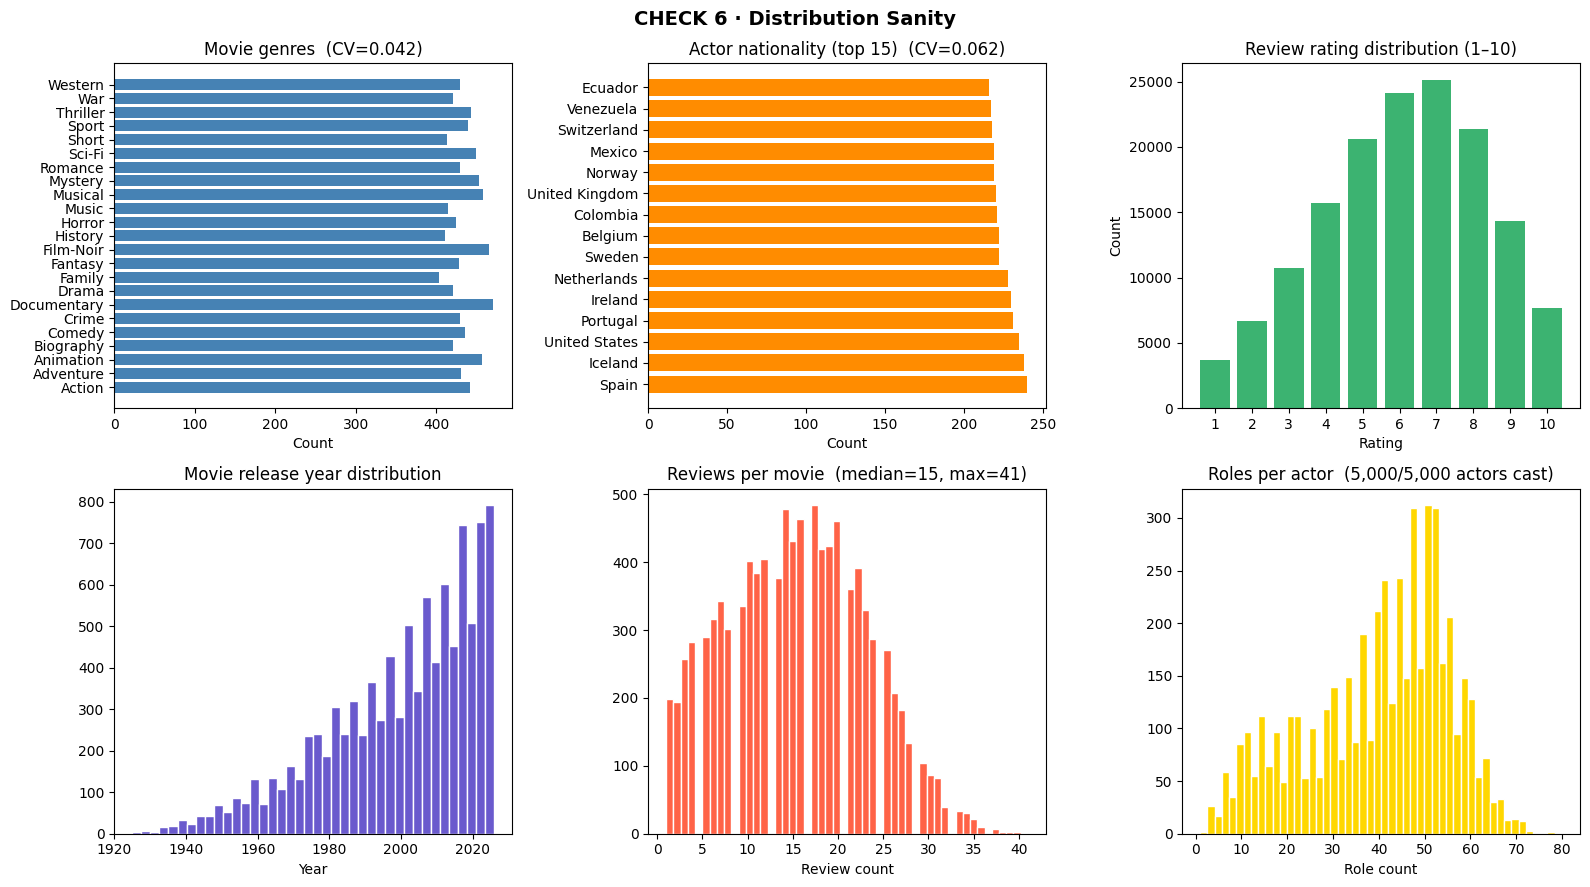

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("CHECK 6 · Distribution Sanity", fontsize=14, fontweight="bold")

ax = axes[0, 0]
genreCounts = movies["genre"].value_counts().sort_index()
ax.barh(genreCounts.index, genreCounts.values, color="steelblue")
ax.set_title("Movie genre distribution")
ax.set_xlabel("Count")
cv = genreCounts.std() / genreCounts.mean()
ax.set_title(f"Movie genres  (CV={cv:.3f})")

ax = axes[0, 1]
natCounts = actors["nationality"].value_counts()
ax.barh(natCounts.index[:15], natCounts.values[:15], color="darkorange")
ax.set_title(f"Actor nationality (top 15)  (CV={natCounts.std()/natCounts.mean():.3f})")
ax.set_xlabel("Count")

ax = axes[0, 2]
ratingCounts = reviews["rating"].value_counts().sort_index()
ax.bar(ratingCounts.index, ratingCounts.values, color="mediumseagreen")
ax.set_title("Review rating distribution (1–10)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax = axes[1, 0]
ax.hist(movies["releaseDate"], bins=40, color="slateblue", edgecolor="white")
ax.set_title("Movie release year distribution")
ax.set_xlabel("Year")

ax = axes[1, 1]
reviewsPerMovie = reviews.groupby("movieID").size()
ax.hist(reviewsPerMovie, bins=50, color="tomato", edgecolor="white")
ax.set_title(f"Reviews per movie  (median={reviewsPerMovie.median():.0f}, "
             f"max={reviewsPerMovie.max()})")
ax.set_xlabel("Review count")

ax = axes[1, 2]
rolesPerActor = roles.groupby("actorID").size()
actorsWithRoles = roles["actorID"].nunique()
ax.hist(rolesPerActor, bins=50, color="gold", edgecolor="white")
ax.set_title(f"Roles per actor  ({actorsWithRoles:,}/{len(actors):,} actors cast)")
ax.set_xlabel("Role count")

plt.tight_layout()
plt.show()